# Desarrollo y productivización de un modelo inteligente para la detección de noticias falsas



##Configuración preliminar

In [1]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/marieladujaric/Verifica-fake-news"
PROJECT_DIR = Path("/content/verifica-fake-news")

if not PROJECT_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_DIR)],
        check=True
    )

os.chdir(PROJECT_DIR)

print("Proyecto preparado correctamente.")
print("Carpeta de trabajo:", Path.cwd())

Proyecto preparado correctamente.
Carpeta de trabajo: /content/verifica-fake-news


In [2]:
import importlib.util
import subprocess
import sys

packages = {
    "pandas": "pandas==2.3.3",
    "numpy": "numpy==2.5.2",
    "sklearn": "scikit-learn==1.7.1",
    "joblib": "joblib==1.5.3",
    "matplotlib": "matplotlib==3.10.5",
    "seaborn": "seaborn==0.13.2",
    "streamlit": "streamlit==1.48.1",
    "kagglehub": "kagglehub>=0.4.3,<2"
}

missing = [
    package
    for module, package in packages.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *missing
    ])

print("Entorno listo.")

Entorno listo.


## 1. Objetivo de negocio y criterio de éxito

**Objetivo:** priorizar contenido que requiere verificación, reduciendo el esfuerzo manual y el tiempo de respuesta. La clase 0 es **falsa** y la clase 1 es **real**.

**KPIs técnicos:** F1 y recall de la clase falsa, ROC-AUC y Brier score (calidad probabilística).  
**KPIs operativos:** latencia, porcentaje de casos inciertos (40–70%), tasa de revisión humana, falsos negativos confirmados y deriva por idioma/fuente.  
**Decisión:** riesgo alto (≥70%) se envía a revisión prioritaria; 40–70% requiere revisión; <40% no significa que la noticia esté verificada.

## 2. Preparación automática del entorno

In [3]:
import importlib.util, subprocess, sys

packages = {
    'pandas': 'pandas==2.3.3', 'numpy': 'numpy==2.5.2',
    'sklearn': 'scikit-learn==1.7.1', 'joblib': 'joblib==1.5.3',
    'matplotlib': 'matplotlib==3.10.5', 'seaborn': 'seaborn==0.13.2',
    'streamlit': 'streamlit==1.48.1', 'kagglehub': 'kagglehub>=0.4.3,<2'
}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print('Entorno listo.')

Entorno listo.


In [4]:
from pathlib import Path
import json, platform, sys, time, shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, brier_score_loss, confusion_matrix,
                             classification_report, RocCurveDisplay)
from sklearn.calibration import CalibrationDisplay
from modeling import (build_pipeline, prepare_dataframe, save_bundle,
                      explain_prediction, fake_probability, get_feature_names)

SEED = 42
BASE = Path.cwd()
DATA_PATH = BASE / 'data' / 'news.csv'
MODEL_PATH = BASE / 'models' / 'fake_news_model.joblib'
FIGURES = BASE / 'figures'
FIGURES.mkdir(exist_ok=True)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='deep')
print('Python:', sys.version.split()[0], '| Plataforma:', platform.system())
print('Dataset:', DATA_PATH)

Python: 3.13.15 | Plataforma: Linux
Dataset: /content/verifica-fake-news/data/news.csv


## 3. Descarga automática, ingesta y auditoría inicial

In [5]:
if not DATA_PATH.exists():
    import kagglehub
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    print('Descargando la base pública desde Kaggle…')
    try:
        downloaded = Path(kagglehub.dataset_download(
            'mucahiddemircan/real-and-fake-news-dataset',
            path='news.csv', output_dir=str(DATA_PATH.parent)
        ))
    except Exception:
        downloaded = Path(kagglehub.dataset_download(
            'mucahiddemircan/real-and-fake-news-dataset',
            output_dir=str(DATA_PATH.parent)
        ))
    candidates = ([downloaded] if downloaded.is_file() else []) + list(DATA_PATH.parent.rglob('news.csv'))
    if not candidates:
        raise FileNotFoundError('Kaggle descargó el recurso, pero no se encontró news.csv')
    source = candidates[0]
    if source.resolve() != DATA_PATH.resolve():
        shutil.copy2(source, DATA_PATH)
else:
    print('Se reutiliza la base local:', DATA_PATH)

raw = pd.read_csv(DATA_PATH)
print('Dimensiones:', raw.shape)
display(raw.head(3))
display(pd.DataFrame({
    'tipo': raw.dtypes.astype(str),
    'nulos': raw.isna().sum(),
    'únicos': raw.nunique(dropna=False)
}))

Descargando la base pública desde Kaggle…


100%|██████████| 119M/119M [00:01<00:00, 104MB/s]


Dimensiones: (45757, 2)


,text,label
0,Gere faults Trump for blurring meaning of 'refugee' and 'terrorist' BERLIN (Reuters) - Actor and activist Richard Ge...,1
1,German parties start to find common ground in coalition talks BERLIN (Reuters) - Parties seeking to form Germany s n...,1
2,Senate Democratic leader says Attorney General Sessions should resign WASHINGTON (Reuters) - Senate Democratic leade...,1


,tipo,nulos,únicos
text,object,0,45757
label,int64,0,2


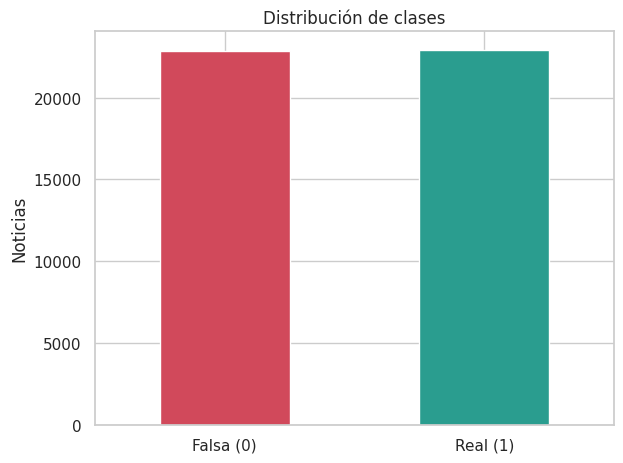

label
0    22857
1    22900
Name: count, dtype: int64


In [6]:
label_counts = raw['label'].value_counts(dropna=False).sort_index()
ax = label_counts.rename(index={0: 'Falsa (0)', 1: 'Real (1)'}).plot.bar(color=['#d1495b', '#2a9d8f'])
ax.set(title='Distribución de clases', xlabel='', ylabel='Noticias')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / 'class_distribution.png', dpi=140)
plt.show()
print(label_counts)

## 4. Limpieza y controles de calidad

Se aplica una limpieza sencilla: normalización Unicode, espacios, URL/correo y HTML. No se eliminan acentos, signos ni palabras funcionales porque contienen señales estilísticas útiles y permiten procesar español, se eliminan nulos, textos demasiado cortos, etiquetas inválidas y duplicados antes de dividir los datos, evitando fuga de información.

,resultado
rows_initial,45757
rows_final,45726
null_rows_removed,0
short_rows_removed,6
invalid_labels_removed,0
duplicate_texts_removed,25
class_counts,"{'0': 22835, '1': 22891}"
rows_used_for_modeling,8000


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,4000.0,2127.0,874.9,39.0,1545.2,2286.5,3000.0,3000.0
1,4000.0,2004.2,959.4,131.0,1044.5,2292.0,3000.0,3000.0


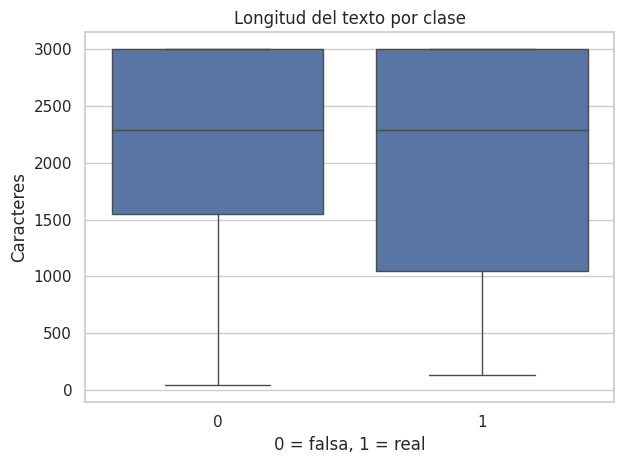

In [7]:
df, cleaning_report = prepare_dataframe(raw)
MAX_PER_CLASS = 4000
if df.groupby('label').size().max() > MAX_PER_CLASS:
    sampled = []
    for label, group in df.groupby('label'):
        sampled.append(group.sample(n=min(MAX_PER_CLASS, len(group)), random_state=SEED))
    df = pd.concat(sampled, ignore_index=True)
cleaning_report['rows_used_for_modeling'] = len(df)
display(pd.Series(cleaning_report, name='resultado'))
df['characters'] = df['text'].str.len()
display(df.groupby('label')['characters'].describe().round(1))
ax = sns.boxplot(data=df.sample(min(10000, len(df)), random_state=SEED), x='label', y='characters', showfliers=False)
ax.set(title='Longitud del texto por clase', xlabel='0 = falsa, 1 = real', ylabel='Caracteres')
plt.tight_layout(); plt.savefig(FIGURES / 'length_by_class.png', dpi=140); plt.show()

## 5. Partición y prevención de fuga


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.20, stratify=df['label'], random_state=SEED
)
print('Entrenamiento:', X_train.shape[0], '| Prueba:', X_test.shape[0])
display(pd.crosstab(index=y_test, columns='test', normalize=True).round(4))

Entrenamiento: 6400 | Prueba: 1600


col_0,test
label,
0,0.5
1,0.5


## 6. Modelo bilingüe e interpretable

**Alcance bilingüe:** la interfaz admite inglés y español y los rasgos no dependen de un diccionario. Sin embargo, esta base es principalmente de idioma inglés, el desempeño en español debe medirse con un corpus español etiquetado antes de uso crítico.

In [9]:
model = build_pipeline()
if MODEL_PATH.exists():
    existing_bundle = joblib.load(MODEL_PATH)
    model = existing_bundle['model']
    training_seconds = existing_bundle['metadata']['metrics'].get('training_seconds', np.nan)
    print('Modelo productivo cargado:', MODEL_PATH)
else:
    started = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - started
    print(f'Entrenamiento completado en {training_seconds:.1f} s')

Modelo productivo cargado: /content/verifica-fake-news/models/fake_news_model.joblib


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator HashingVectorizer from version 1.7.1 when using version 1.6.1. This might lead to breaking co

## 7. Evaluación de clasificación y probabilidad

In [10]:
pred = model.predict(X_test)
fake_index = list(model.classes_).index(0)
p_fake = model.predict_proba(X_test)[:, fake_index]
y_fake = (y_test == 0).astype(int)

metrics = {
    'accuracy': accuracy_score(y_test, pred),
    'precision_fake': precision_score(y_test, pred, pos_label=0),
    'recall_fake': recall_score(y_test, pred, pos_label=0),
    'f1_fake': f1_score(y_test, pred, pos_label=0),
    'roc_auc_fake': roc_auc_score(y_fake, p_fake),
    'brier_fake': brier_score_loss(y_fake, p_fake),
    'test_rows': len(y_test),
    'training_seconds': round(training_seconds, 2),
}
display(pd.Series(metrics).to_frame('valor').style.format('{:.4f}'))
print(classification_report(y_test, pred, labels=[0, 1], target_names=['fake', 'real']))

,valor
accuracy,0.9738
precision_fake,0.9679
recall_fake,0.9800
f1_fake,0.9739
roc_auc_fake,0.9961
brier_fake,0.0247
test_rows,1600.0000
training_seconds,20.3600


              precision    recall  f1-score   support

        fake       0.97      0.98      0.97       800
        real       0.98      0.97      0.97       800

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600



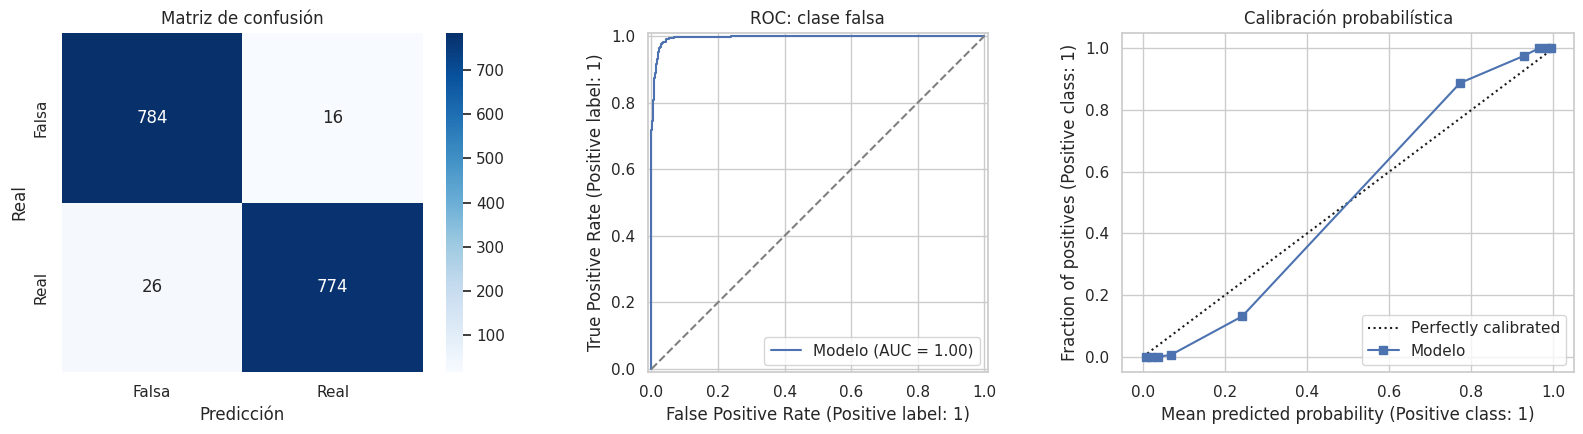

In [11]:
cm = confusion_matrix(y_test, pred, labels=[0, 1])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Falsa', 'Real'], yticklabels=['Falsa', 'Real'])
axes[0].set(title='Matriz de confusión', xlabel='Predicción', ylabel='Real')
RocCurveDisplay.from_predictions(y_fake, p_fake, ax=axes[1], name='Modelo')
axes[1].plot([0,1], [0,1], '--', color='gray'); axes[1].set_title('ROC: clase falsa')
CalibrationDisplay.from_predictions(y_fake, p_fake, n_bins=10, strategy='quantile', ax=axes[2], name='Modelo')
axes[2].set_title('Calibración probabilística')
plt.tight_layout(); plt.savefig(FIGURES / 'model_evaluation.png', dpi=140); plt.show()

## 8. Interpretabilidad global


,feature,direction,coefficient
0,char__hash_4060,fake,-4.347428
1,word__via,fake,-3.324774
2,word__video,fake,-3.109987
3,char__hash_641,fake,-2.249088
4,word__us,fake,-2.194586
5,char__hash_1599,fake,-2.094864
6,word__url,fake,-1.949441
7,char__hash_827,fake,-1.934921
8,word__email,fake,-1.802723
9,word__the us,fake,-1.792708


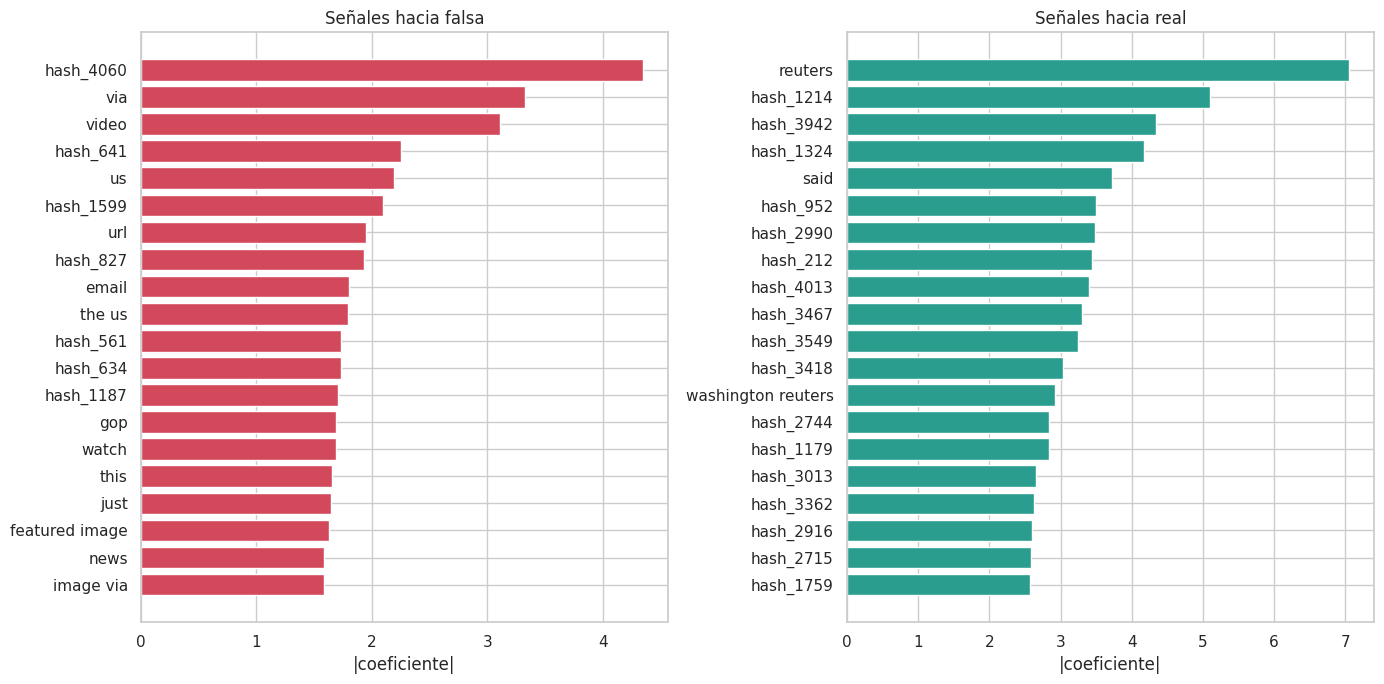

In [12]:
feature_names = get_feature_names(model)
coef = model.named_steps['classifier'].coef_[0]
top_fake = np.argsort(coef)[:20]
top_real = np.argsort(coef)[-20:][::-1]
importance = pd.concat([
    pd.DataFrame({'feature': feature_names[top_fake], 'direction': 'fake', 'coefficient': coef[top_fake]}),
    pd.DataFrame({'feature': feature_names[top_real], 'direction': 'real', 'coefficient': coef[top_real]})
])
display(importance)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, idx, title, color in [(axes[0], top_fake, 'Señales hacia falsa', '#d1495b'), (axes[1], top_real, 'Señales hacia real', '#2a9d8f')]:
    vals = np.abs(coef[idx]); labels = [x.replace('word__','').replace('char__','') for x in feature_names[idx]]
    ax.barh(labels[::-1], vals[::-1], color=color); ax.set_title(title); ax.set_xlabel('|coeficiente|')
plt.tight_layout(); plt.savefig(FIGURES / 'global_interpretability.png', dpi=140); plt.show()

## 9. Interpretabilidad local y prueba bilingüe

In [14]:
examples = {
    "English": "Scientists published a peer-reviewed study and provided the dataset and methodology for independent review.",
    "Español": "Un mensaje viral asegura, sin citar fuentes ni aportar evidencia verificable, que un producto cura todas las enfermedades."
}

rows = []

for language, article in examples.items():
    probability = fake_probability(model, article)

    rows.append({
        "language": language,
        "probability_fake": probability,
        "text": article
    })

    print()
    print(language, f"P(falsa)={probability:.1%}")

    display(
        pd.DataFrame(
            explain_prediction(model, article, top_n=8)
        )
    )

display(pd.DataFrame(rows))


English P(falsa)=70.5%


,feature,direction,contribution
0,hash_952,real,0.237180
1,hash_1780,real,0.141282
2,hash_2761,fake,0.101584
3,hash_1959,real,0.100027
4,hash_1412,real,0.098373
5,hash_3852,real,0.098005
6,scientists,real,0.095628
7,review,real,0.078247



Español P(falsa)=51.6%


,feature,direction,contribution
0,hash_1759,real,0.347400
1,hash_1214,real,0.344193
2,un,fake,0.320829
3,las,real,0.320476
4,hash_394,real,0.158102
5,hash_1599,fake,0.141236
6,hash_365,real,0.094151
7,hash_1732,real,0.081924


,language,probability_fake,text
0,English,0.705118,Scientists published a peer-reviewed study and provided the dataset and methodology for independent review.
1,Español,0.516428,"Un mensaje viral asegura, sin citar fuentes ni aportar evidencia verificable, que un producto cura todas las enferme..."


## 10. Análisis de errores y umbral de negocio


,threshold,precision_fake,recall_fake,f1_fake,review_rate
0,0.10,0.828,0.999,0.905,0.603
1,0.15,0.882,0.999,0.937,0.566
2,0.20,0.912,0.999,0.953,0.548
3,0.25,0.930,0.998,0.963,0.536
4,0.30,0.939,0.995,0.966,0.530
5,0.35,0.953,0.992,0.972,0.521
6,0.40,0.959,0.988,0.973,0.515
7,0.45,0.961,0.982,0.972,0.511
8,0.50,0.968,0.980,0.974,0.506
9,0.55,0.973,0.974,0.973,0.501


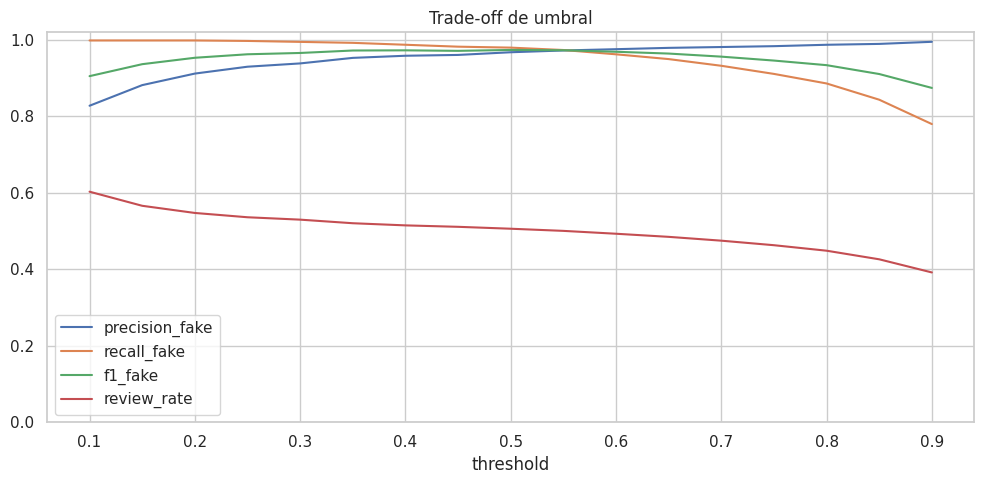

In [15]:
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_table = []
for threshold in thresholds:
    predicted_fake = p_fake >= threshold
    threshold_table.append({
        'threshold': threshold,
        'precision_fake': precision_score(y_fake, predicted_fake, zero_division=0),
        'recall_fake': recall_score(y_fake, predicted_fake),
        'f1_fake': f1_score(y_fake, predicted_fake),
        'review_rate': predicted_fake.mean(),
    })
threshold_table = pd.DataFrame(threshold_table)
display(threshold_table.round(3))
threshold_table.plot(x='threshold', y=['precision_fake','recall_fake','f1_fake','review_rate'], figsize=(10,5))
plt.ylim(0,1.02); plt.title('Trade-off de umbral'); plt.tight_layout();
plt.savefig(FIGURES / 'threshold_tradeoff.png', dpi=140); plt.show()

In [16]:
error_df = pd.DataFrame({'text': X_test, 'actual': y_test, 'prediction': pred, 'p_fake': p_fake})
errors = error_df[error_df['actual'] != error_df['prediction']].copy()
errors['error_type'] = np.where(errors['actual'].eq(0), 'falsa_no_detectada', 'real_marcada_falsa')
display(errors.groupby('error_type')['p_fake'].agg(['count','mean','min','max']).round(3))
display(errors.sort_values('p_fake').groupby('error_type').head(3)[['error_type','actual','prediction','p_fake','text']])

,count,mean,min,max
error_type,,,,
falsa_no_detectada,16,0.357,0.084,0.492
real_marcada_falsa,26,0.722,0.506,0.924


,error_type,actual,prediction,p_fake,text
2300,falsa_no_detectada,0,1,0.083982,FORD’S NEW CEO SNUBS President Trump...Will Build Focus In China...Export To U.S. Ford will export the next-generati...
1081,falsa_no_detectada,0,1,0.218749,"ON THE MOVE: [Video] Iranians, Russians And Syrians Set Up Coordination Cell In Iraq How many more days remain in ou..."
161,falsa_no_detectada,0,1,0.290609,"COPYCAT MUSLIM TERRORIST ARRESTED With Assault Weapons, Knives Drives Into Busy Shopping Area At High Speed [VIDEO] ..."
7776,real_marcada_falsa,1,0,0.506021,"NFL: 'Taking the knee' anthem protest to be discussed with clubs NFL teams have been ""taking the knee"" during the Am..."
4614,real_marcada_falsa,1,0,0.514607,Instant View: Reaction to disbanding of Trump business councils (Reuters) - U.S. President Donald Trump disbanded tw...
7828,real_marcada_falsa,1,0,0.517624,Anderson Cooper shows the scariest clowns Chat with us in Facebook Messenger. Find out what's happening in the world...


## 11. Versionado y artefactos de producción


In [17]:
metrics['confusion_matrix_labels_0_1'] = cm.tolist()
metadata = save_bundle(model, MODEL_PATH, metrics, cleaning_report)
report = classification_report(y_test, pred, labels=[0,1], target_names=['fake','real'], output_dict=True)
(MODEL_PATH.parent / 'classification_report.json').write_text(json.dumps(report, indent=2), encoding='utf-8')
manifest = {
    'python': sys.version, 'platform': platform.platform(),
    'sklearn': __import__('sklearn').__version__, 'pandas': pd.__version__,
    'seed': SEED, 'data_rows': len(df), 'model_sha256': metadata['sha256']
}
(MODEL_PATH.parent / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
display(pd.Series(metadata))
print('Modelo guardado en:', MODEL_PATH)

,0
model_version,1.0.0
created_at_utc,2026-09-03T23:16:47.254005+00:00
fake_label,0
real_label,1
supported_interface_languages,"[es, en]"
training_language,primarily English
metrics,"{'accuracy': 0.97375, 'precision_fake': 0.9679012345679012, 'recall_fake': 0.98, 'f1_fake': 0.9739130434782609, 'roc..."
cleaning_report,"{'rows_initial': 45757, 'rows_final': 45726, 'null_rows_removed': 0, 'short_rows_removed': 6, 'invalid_labels_remove..."
sha256,d178536e8ca4b721136f4cac90a0c8bced0dcaebadb65660bcb7e5ebb6629d2d


Modelo guardado en: /content/verifica-fake-news/models/fake_news_model.joblib


## 12. Interpretabilidad, sesgos, seguridad y gobierno

- **Interpretabilidad:** explicación global por coeficientes y local por contribuciones; usarla para detectar atajos como nombres de agencias.
- **Sesgo y deriva:** evaluar métricas separadas por idioma, fuente, tema y periodo. La ausencia de metadatos en esta base limita esa auditoría.
- **Privacidad:** no guardar el texto en logs; conservar solo hash y métricas técnicas salvo consentimiento y política explícita.
- **Seguridad:** limitar tamaño, sanitizar entradas, autenticar el servicio, cifrar tránsito y almacenamiento, y restringir acceso al modelo/logs.
- **Gobierno:** ficha de modelo, propietario, versión, aprobación humana, trazabilidad, caducidad, rollback y criterios de retirada.
- **Limitación central:** detección lingüística ≠ verificación factual. Para elevar la solución se debe integrar recuperación de fuentes confiables y contrastación de afirmaciones.

### Conclusión

El prototipo queda transformado en un activo reproducible y desplegable, con probabilidad, explicación, interfaz bilingüe, versionado y monitorización. El siguiente incremento de valor es construir y validar un corpus español representativo del contexto de la organización.